In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

In [2]:
#@title 1. CONFIG AND DEVICE

n_samples = 10000
n_repeats = 10      # number of seeds
d_c = 5
d_s = 5
beta = 0.5
seed0 = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ==================
# function: set seed
# ==================
def set_seed(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Using device: cuda


In [3]:
#@title 2. HELPERS

# ==========================
# function: split parameters
# ==========================
def split_theta(theta, d_c):
    return theta[:d_c], theta[d_c:]

# ===================================
# function: split second moment block
# ===================================
def block_split(Sigma, d_c):
    """
    Returns Sigma_cc, Sigma_cs, Sigma_sc, Sigma_ss.
    """
    return (Sigma[:d_c, :d_c], Sigma[:d_c, d_c:],
            Sigma[d_c:, :d_c], Sigma[d_c:, d_c:])

# =========================================================
# function: orient feature data using labels from annotator
# =========================================================
def orient_data(D_phi, y):
    """
    Convert (features, labels) to DPO-oriented data X = (2y-1) * D_phi.
    """
    if y is not None:
        labels = (2.0 * y - 1.0)
        return labels * D_phi
    else:
        return D_phi

# =========================
# function: plot beta sweep
# =========================
def plot_beta_sweep(results, level):
    """Plot beta sweep with 1σ bands."""
    betas = results["betas"]
    curvature_corrected = "kappa_mean" in results

    c_blue, c_red, c_green = '#1565C0', '#C62828', '#2E7D32'

    def mean_std(key):
        return np.array(results[f"{key}_mean"]), np.array(results[f"{key}_std"])

    n_plots = 3 if curvature_corrected else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

    # Plot 1: ||θ_s|| vs β
    ax = axes[0]
    for key, color, label in [
        ("theta_s_dpo", c_red, "DPO"),
        ("theta_s_lin", c_blue, "Linear"),
    ]:
        m, s = mean_std(key)
        ax.plot(betas, m, 'o-', color=color, lw=2, markersize=5, label=label)
        ax.fill_between(betas, m - s, m + s, color=color, alpha=0.15)
    if curvature_corrected:
        m, s = mean_std("theta_s_corr")
        ax.plot(betas, m, 's--', color=c_green, lw=2, markersize=5, label='κ-corrected')
        ax.fill_between(betas, m - s, m + s, color=c_green, alpha=0.15)
    ax.set_xscale('log')
    ax.set_xlabel(r'$\beta$', fontsize=14)
    ax.set_ylabel(r'$\|\tilde{\theta}_s^*\|$', fontsize=14)
    ax.set_title(f'{level}: Spurious Norm vs β')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Plot 2: Relative error vs β
    ax = axes[1]
    m, s = mean_std("rel_err")
    ax.plot(betas, m, 'o-', color=c_blue, lw=2, markersize=5, label='Linear vs DPO')
    ax.fill_between(betas, m - s, m + s, color=c_blue, alpha=0.15)
    if curvature_corrected:
        m, s = mean_std("rel_err_corr")
        ax.plot(betas, m, 's--', color=c_green, lw=2, markersize=5, label='κ-corrected vs DPO')
        ax.fill_between(betas, m - s, m + s, color=c_green, alpha=0.15)
    ax.set_xscale('log')
    ax.set_xlabel(r'$\beta$', fontsize=14)
    ax.set_ylabel('Rel. Error', fontsize=14)
    ax.set_title(f'{level}: Linearization Error vs β')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Plot 3: κ vs β (only if curvature corrected)
    if curvature_corrected:
        ax = axes[2]
        m, s = mean_std("kappa")
        ax.plot(betas, m, 'o-', color='purple', lw=2, markersize=5)
        ax.fill_between(betas, m - s, m + s, color='purple', alpha=0.15)
        ax.axhline(0.25, color='gray', ls='--', lw=1.5, alpha=0.5, label='κ = 0.25 (linear)')
        ax.set_xscale('log')
        ax.set_xlabel(r'$\beta$', fontsize=14)
        ax.set_ylabel(r'$\kappa$', fontsize=14)
        ax.set_title(f'{level}: Mean-Field Curvature')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'Beta Sweep: {level}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'beta_sweep_{level}.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# =============================
# function: plot SGD experiment
# =============================
def plot_sgd_experiment(res):
    """Three-panel plot from sgd_experiment results."""
    level = res["level"]
    beta = res["beta"]
    d_c = res["d_c"]
    traj = res["traj"]
    margins = res["margins"]
    n_runs, steps_plus_1, d = traj.shape
    steps = steps_plus_1 - 1
    curvature_corrected = "theta_corr" in res

    theta_s_lin = res["theta_lin"][d_c:]
    theta_s_dpo = res["theta_dpo"][d_c:]

    final_s = traj[:, -1, d_c:]
    final_s_norms = np.linalg.norm(final_s, axis=1)

    c_blue, c_red, c_green, c_yellow = '#1565C0', '#C62828', '#2E7D32', '#F9A825'

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: ||θ_s|| trajectory
    ax = axes[0]
    time = np.arange(steps_plus_1)
    for run in range(min(n_runs, 30)):
        ax.plot(time, np.linalg.norm(traj[run, :, d_c:], axis=1),
                color=c_red, alpha=0.06, lw=0.5)
    mean_s = np.linalg.norm(traj.mean(axis=0)[:, d_c:], axis=1)
    ax.plot(time, mean_s, color=c_red, lw=2.0, label='SGD mean')
    ax.axhline(np.linalg.norm(theta_s_lin), color=c_blue, ls='--', lw=2.0, label='Linear')
    ax.axhline(np.linalg.norm(theta_s_dpo), color=c_green, ls=':', lw=2.0, label='DPO (GD)')
    if curvature_corrected:
        theta_s_corr = res["theta_corr"][d_c:]
        ax.axhline(np.linalg.norm(theta_s_corr), color='purple', ls='-.', lw=2.0, label='κ-corrected')
    ax.set_xlabel('SGD iteration', fontsize=14)
    ax.set_ylabel(r'$\|\tilde{\theta}_s\|$', fontsize=14)
    ax.set_title(f'{level}: Spurious Norm Trajectory')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Plot 2: Margin over training
    ax = axes[1]
    for run in range(min(n_runs, 30)):
        ax.plot(np.arange(steps), margins[run], color='gray', alpha=0.05, lw=0.5)
    mean_m = margins.mean(axis=0)
    ax.plot(np.arange(steps), mean_m, color='black', lw=2.0,
            label=r'mean max $|\beta\theta^\top x|$')
    ax.axhline(1.0, color=c_red, ls='--', lw=2.0, alpha=0.8, label='= 1')
    ax.axhline(0.5, color=c_yellow, ls='--', lw=2.0, alpha=0.8, label='= 0.5')
    ax.set_xlabel('SGD iteration', fontsize=14)
    ax.set_ylabel(r'max $|\beta\theta^\top x|$', fontsize=14)
    ax.set_title(f'{level}: Local Regime')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

    # Plot 3: Bar comparison
    ax = axes[2]
    vals = [np.linalg.norm(theta_s_lin), np.linalg.norm(theta_s_dpo), final_s_norms.mean()]
    errs = [0, 0, final_s_norms.std()]
    labels_bar = ['Linear', 'DPO (GD)', 'SGD']
    bar_colors = [c_blue, c_green, c_red]

    if curvature_corrected:
        theta_s_corr = res["theta_corr"][d_c:]
        vals.insert(1, np.linalg.norm(theta_s_corr))
        errs.insert(1, 0)
        labels_bar.insert(1, 'κ-corr')
        bar_colors.insert(1, 'purple')

    x = np.arange(len(vals))
    ax.bar(x, vals, yerr=errs, color=bar_colors, alpha=0.85, capsize=5,
           edgecolor='black', linewidth=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_bar, fontsize=12)
    ax.set_ylabel(r'$\|\tilde{\theta}_s^*\|$', fontsize=14)
    ax.set_title(f'{level}: Final Spurious Norm')
    ax.grid(True, alpha=0.3, axis='y')

    suptitle = f'SGD Experiment: {level} (β={beta})'
    if curvature_corrected:
        suptitle += f', κ={res["kappa"]:.4f}'
    fig.suptitle(suptitle, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'sgd_experiment_{level}.pdf', dpi=300, bbox_inches='tight')
    plt.show()

In [4]:
#@title 3. SOLVERS

# ==================================
# function: solve linear equilibrium
# ==================================
def linear_solution(mu, Sigma, beta):
    """
    Closed-form linearized equilibrium: \theta^* = (2/\beta) (Sigma)^{-1} mu.
    """
    return (2.0 / beta) * torch.linalg.solve(Sigma, mu)

# ============================================================
# function: second-order / curvature correction to linear soln
# ============================================================
def linear_solution_corrected(mu, Sigma, beta, X, theta_dpo):
    """
    Curvature-corrected (second-order) linearized equilibrium.

    \theta_corr = (0.25 / kappa) · \theta_lin

    where:
        \theta_lin = (2/\beta) (Sigma)^{-1} mu
        kappa = E[sigma(\beta \theta_DPO^\top x)(1 - sigma(\beta \theta_DPO^\top x))]

    kappa is measured at the converged DPO solution.
    """
    theta_lin = (2.0 / beta) * torch.linalg.solve(Sigma, mu)
    kappa = estimate_kappa(X, theta_dpo, beta)
    corr = 0.25 / kappa if kappa > 0 else 1.0
    theta_corr = corr * theta_lin

    return theta_corr, kappa

# ================================
# function: Schur-based prediction
# ================================
def schur_predict(mu, Sigma, beta, d_c):
    """
    Schur-complement prediction for the spurious block.
    \theta_s = (2/\beta) S_s^{-1} (mu_s − Sigma_sc Sigma_cc^{-1} mu_c) - recover paper version via Woodbury/Schur inverse identity
    where S_s = Sigma_ss − Sigma_sc Sigma_cc^{-1} Sigma_cs.
    Also returns \theta_c for completeness.
    """
    Sigma_cc, Sigma_cs, Sigma_sc, Sigma_ss = block_split(Sigma, d_c)
    mu_c, mu_s = mu[:d_c], mu[d_c:]

    Sigma_cc_inv = torch.linalg.inv(Sigma_cc)
    S_s = Sigma_ss - Sigma_sc @ Sigma_cc_inv @ Sigma_cs
    S_s_inv = torch.linalg.inv(S_s)

    theta_s = (2.0 / beta) * S_s_inv @ (mu_s - Sigma_sc @ Sigma_cc_inv @ mu_c)

    # Also recover \theta_c from the causal Schur complement
    S_c = Sigma_cc - Sigma_cs @ torch.linalg.inv(Sigma_ss) @ Sigma_sc
    Sigma_ss_inv = torch.linalg.inv(Sigma_ss)
    theta_c = (2.0 / beta) * torch.linalg.inv(S_c) @ (mu_c - Sigma_cs @ Sigma_ss_inv @ mu_s)

    return torch.cat([theta_c, theta_s])


# ==================
# function: DPO loss
# ==================
def dpo_loss(theta, X, beta):
    """
    DPO loss: -E[log sigma(\beta \theta^\top x)].
    """
    z = beta * (X @ theta)
    return -torch.mean(F.logsigmoid(z))

# ==============================
# function: gradient of dpo loss
# ==============================
def dpo_grad(theta, X, beta):
    """
    Gradient of DPO loss.
    """
    z = beta * (X @ theta)
    w = 1.0 - torch.sigmoid(z)  # w = \sigma(-z)
    return -beta * (X.T @ w) / X.shape[0]

# ===================
# function: solve DPO
# ===================
def solve_dpo(X, beta, lr=0.05, steps=30000, tol=1e-10):
    """
    Solve DPO via gradient descent. Returns \theta on the same device as X.
    """
    d = X.shape[1]
    theta = torch.zeros(d, dtype=X.dtype, device=X.device)
    for step in range(steps):
        g = dpo_grad(theta, X, beta)
        theta = theta - lr * g
        if torch.linalg.norm(g) < tol:
            break
    return theta

<>:25: SyntaxWarning: invalid escape sequence '\k'
<>:25: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_6021/2213538288.py:25: SyntaxWarning: invalid escape sequence '\k'
  \kappa is measured at the converged DPO solution.


In [5]:
#@title 4. MOMENTS & DIAGNOSTICS

# ===========================
# Empirical moments from data
# ===========================
def empirical_moments(D_phi, y=None):
    """
    Compute empirical hat Sigma = (1/n) X^\top X  and  hat mu.

    If y is provided (BT levels ii/iii):
        hat mu = (1/n) X^\top(2y − 1)      [label-oriented mean]
    If y is None (level i, data is already feature differences):
        hat mu = (1/n) Sigma 1 = mean(X)  [direct mean]
    """
    n = D_phi.shape[0]
    Sigma_hat = (D_phi.T @ D_phi) / n
    if y is not None:
        mu_hat = (D_phi.T @ (2.0 * y - 1.0)).squeeze() / n
    else:
        mu_hat = D_phi.mean(dim=0)
    return mu_hat, Sigma_hat

# ==================
# Local regime check
# ==================
def local_regime_check(D_phi, y, theta, beta, d_c):
    """
    Check whether the solution \theta is in the local linear regime.
    Reports margin statistics over the dataset.

    Returns dict with:
        max_margin:  max_i |\beta \theta^\top x_i|
        mean_margin: mean_i |\beta \theta^\top x_i|
        p95_margin:  95th percentile of |\beta \theta^\top x_i|
        frac_above_1: fraction of data points with |\theta \theta^\top x_i| > 1
        frac_above_05: fraction of data points with |\theta \theta^\top x_i| > 0.5
    """
    X = orient_data(D_phi, y)
    z = beta * (X @ theta)
    abs_z = z.abs()

    result = {
        "max_margin": abs_z.max().item(),
        "mean_margin": abs_z.mean().item(),
        "median_margin": abs_z.median().item(),
        "p95_margin": abs_z.quantile(0.95).item(),
        "frac_above_1": (abs_z > 1.0).float().mean().item(),
        "frac_above_05": (abs_z > 0.5).float().mean().item(),
    }

    theta_c, theta_s = split_theta(theta, d_c)
    print(f"  Local regime check:")
    print(f"    max  |β θ⊤x| = {result['max_margin']:.4f}")
    print(f"    mean |β θ⊤x| = {result['mean_margin']:.4f}")
    print(f"    p95  |β θ⊤x| = {result['p95_margin']:.4f}")
    print(f"    frac > 1.0:     {result['frac_above_1']:.4f}")
    print(f"    frac > 0.5:     {result['frac_above_05']:.4f}")

    return result

# ==========================================
# function: estimate second order correction
# ==========================================
def estimate_kappa(X, theta, beta):
    """
    Estimate mean-field curvature kappa = E[sigma(z)(1 - sigma(z))]
    where z = \beta \theta^\top x, evaluated at the given θ.

    In the strict linear regime (z ≈ 0), κ ≈ 0.25.
    As logits grow, κ decreases (sigmoid saturates).
    """
    z = beta * (X @ theta)
    p = torch.sigmoid(z)
    kappa = torch.mean(p * (1.0 - p)).item()
    return kappa


# ====================
# Curvature diagnostic
# ====================
def curvature_diagnostic(theta_dpo, theta_lin, d_c):
    """
    Measure the attenuation factor: how much the linear prediction
    underestimates the DPO solution.

    For each block (causal, spurious), computes:
      ratio = ||\theta_dpo|| / ||\theta_lin||
      cosine similarity (direction agreement)
    """
    tc_dpo, ts_dpo = split_theta(theta_dpo, d_c)
    tc_lin, ts_lin = split_theta(theta_lin, d_c)

    # Norms
    norm_c_dpo, norm_c_lin = tc_dpo.norm().item(), tc_lin.norm().item()
    norm_s_dpo, norm_s_lin = ts_dpo.norm().item(), ts_lin.norm().item()

    # Ratios
    ratio_c = norm_c_dpo / (norm_c_lin + 1e-12)
    ratio_s = norm_s_dpo / (norm_s_lin + 1e-12)

    # Cosine similarities
    cos_c = (tc_dpo @ tc_lin).item() / (norm_c_dpo * norm_c_lin + 1e-12)
    cos_s = (ts_dpo @ ts_lin).item() / (norm_s_dpo * norm_s_lin + 1e-12)

    print(f"  Curvature diagnostic:")
    print(f"    Causal:   ||DPO||/||Lin|| = {ratio_c:.4f},  cos = {cos_c:.4f}")
    print(f"    Spurious: ||DPO||/||Lin|| = {ratio_s:.4f},  cos = {cos_s:.4f}")

    return {
        "ratio_c": ratio_c, "ratio_s": ratio_s,
        "cos_c": cos_c, "cos_s": cos_s,
    }

In [6]:
#@title 5. DATA GENERATION

# ========================================
# Data Generation — Level (i): No BT model
# ========================================
def make_no_BT(n, d_c, d_s, seed=None, mu_scale=1.0):
    """
    D_phi ~ N(mu, Cov) with arbitrary mu and positive-definite Cov.
    mu_scale controls ||mu|| to stay in the linear regime (small mu_scale -> linear).
    Returns: D_phi, mu_true, Cov_true, Sigma_true (= Cov + mu mu^\top), d_c
    """
    if seed is not None:
        set_seed(seed)
    d = d_c + d_s

    # Arbitrary mean (scaled)
    mu = mu_scale * (torch.rand(d, device=DEVICE) * 2 - 1)

    # Arbitrary positive-definite covariance (correlation matrix)
    A = torch.randn(d, d, device=DEVICE)
    Cov_raw = A @ A.T
    diag_inv_sqrt = torch.diag(1.0 / torch.sqrt(torch.diag(Cov_raw)))
    # Cov = diag_inv_sqrt @ Cov_raw @ diag_inv_sqrt
    corr_matrix = diag_inv_sqrt @ Cov_raw @ diag_inv_sqrt

    Cov = 0.3 * torch.eye(d, device=DEVICE) + 0.7 * corr_matrix  # well-conditioned

    # Second moment \Sigma = Cov + \mu \mu^\top
    Sigma = Cov + torch.outer(mu, mu)

    # Sample
    dist = torch.distributions.MultivariateNormal(mu, Cov)
    D_phi = dist.sample((n,))

    return D_phi, mu, Cov, Sigma

# ======================================================
# Data Generation — Level (ii): BT causal-only annotator
# ======================================================
@torch.no_grad()
def make_BT_causal_only(n, d_c, d_s, theta_c_star, beta, rho=0.0, seed=None):
    """
    Features: D_phi = [D_phi_c; D_phi_s], where D_phi_s has rho-correlation
    with D_phi_c (up to min(d_c, d_s) dimensions).
    Labels: p = sigma(theta_c^\top D_phi_c) — spurious features don't affect labels.
    """
    if seed is not None:
        set_seed(seed)

    D_phi_c = torch.randn(n, d_c, device=DEVICE)
    D_phi_s = torch.randn(n, d_s, device=DEVICE)

    # Inject correlation
    min_d = min(d_c, d_s)
    D_phi_s[:, :min_d] = (rho * D_phi_c[:, :min_d] +
                          (1 - rho**2)**0.5 * D_phi_s[:, :min_d])

    D_phi = torch.cat([D_phi_c, D_phi_s], dim=1)

    # Labels from causal-only teacher
    logits = D_phi_c @ theta_c_star
    p = torch.sigmoid(logits).unsqueeze(1)
    y = (torch.rand(n, 1, device=DEVICE) < p).float()

    return D_phi, y

# ================================================
# Data Generation — Level (iii): BT full annotator
# ================================================
@torch.no_grad()
def make_BT_full(n, d_c, d_s, theta_c_star, theta_s_star, beta, seed=None):
    """
    Features: D_phi = [D_phi_c; D_phi_s] ~ N(0, I).
    Labels: p = sigma(\theta^\top D_phi) — full annotator uses both causal and spurious.
    """
    if seed is not None:
        set_seed(seed)

    D_phi_c = torch.randn(n, d_c, device=DEVICE)
    D_phi_s = torch.randn(n, d_s, device=DEVICE)
    D_phi = torch.cat([D_phi_c, D_phi_s], dim=1)

    theta_star = torch.cat([theta_c_star, theta_s_star])
    logits = D_phi @ theta_star
    p = torch.sigmoid(logits).unsqueeze(1)
    y = (torch.rand(n, 1, device=DEVICE) < p).float()

    return D_phi, y


In [7]:
#@title 6. EXPERIMENTS

# ============================
# Single-run equilibrium check
# ============================
def check_equilibrium(D_phi, y, beta, d_c, level_name="",
                      mu_true=None, Sigma_true=None):
    """
    For a single dataset:
      1. Solve DPO empirically
      2. Compute linear closed-form from empirical moments
      3. Compute Schur prediction from empirical moments
      4. (If available) compute linear closed-form from true moments
      5. Run local regime check
      6. Run curvature diagnostic
    """
    d = D_phi.shape[1]
    d_s = d - d_c

    # --- Orient and solve DPO ---
    X_dpo = orient_data(D_phi, y)
    theta_dpo = solve_dpo(X_dpo, beta, lr=0.05, steps=30000, tol=1e-10)

    # --- Empirical moments ---
    mu_hat, Sigma_hat = empirical_moments(D_phi, y)

    # --- Linear closed-form (empirical moments) ---
    theta_lin = linear_solution(mu_hat, Sigma_hat, beta)

    # --- Schur prediction (empirical moments) ---
    theta_schur = schur_predict(mu_hat, Sigma_hat, beta, d_c)

    # --- Linear closed-form (true moments, if available) ---
    theta_lin_true = None
    if mu_true is not None and Sigma_true is not None:
        theta_lin_true = linear_solution(mu_true, Sigma_true, beta)

    # --- Report ---
    theta_c_dpo, theta_s_dpo = split_theta(theta_dpo, d_c)
    theta_c_lin, theta_s_lin = split_theta(theta_lin, d_c)
    theta_c_sch, theta_s_sch = split_theta(theta_schur, d_c)

    print(f"\n{'='*65}")
    print(f"  {level_name}   |   beta = {beta}")
    print(f"{'='*65}")
    print(f"  {'Method':<25} {'||θ_c||':>10} {'||θ_s||':>10} {'||θ||':>10}")
    print(f"  {'-'*55}")
    print(f"  {'DPO (empirical)':<25} {theta_c_dpo.norm().item():>10.4f} "
          f"{theta_s_dpo.norm().item():>10.4f} {theta_dpo.norm().item():>10.4f}")
    print(f"  {'Linear (emp. moments)':<25} {theta_c_lin.norm().item():>10.4f} "
          f"{theta_s_lin.norm().item():>10.4f} {theta_lin.norm().item():>10.4f}")
    print(f"  {'Schur  (emp. moments)':<25} {theta_c_sch.norm().item():>10.4f} "
          f"{theta_s_sch.norm().item():>10.4f} {theta_schur.norm().item():>10.4f}")

    if theta_lin_true is not None:
        tc, ts = split_theta(theta_lin_true, d_c)
        print(f"  {'Linear (true moments)':<25} {tc.norm().item():>10.4f} "
              f"{ts.norm().item():>10.4f} {theta_lin_true.norm().item():>10.4f}")

    # Relative errors (spurious block)
    rel_lin = (theta_s_lin - theta_s_dpo).norm() / (theta_s_dpo.norm() + 1e-12)
    rel_sch = (theta_s_sch - theta_s_dpo).norm() / (theta_s_dpo.norm() + 1e-12)
    print(f"\n  Rel. error ||θ_s|| (Linear  vs DPO): {rel_lin.item():.4f}")
    print(f"  Rel. error ||θ_s|| (Schur   vs DPO): {rel_sch.item():.4f}")

    print(f"\n  θ_s (DPO):    {theta_s_dpo.cpu().numpy().round(4)}")
    print(f"  θ_s (Linear): {theta_s_lin.cpu().numpy().round(4)}")
    print(f"  θ_s (Schur):  {theta_s_sch.cpu().numpy().round(4)}")

    # Local regime check
    regime = local_regime_check(D_phi, y, theta_dpo, beta, d_c)

    # Curvature diagnostic
    curv = curvature_diagnostic(theta_dpo, theta_lin, d_c)

    return {
        "theta_dpo": theta_dpo,
        "theta_lin": theta_lin,
        "theta_schur": theta_schur,
        "theta_s_dpo_norm": theta_s_dpo.norm().item(),
        "theta_s_lin_norm": theta_s_lin.norm().item(),
        "theta_s_schur_norm": theta_s_sch.norm().item(),
        "rel_err_lin": rel_lin.item(),
        "rel_err_schur": rel_sch.item(),
        "regime": regime,
        "curvature": curv,
    }

# =================
# Multi-seed runner
# =================
def run_multi_seed(level, n_repeats, n_samples, d_c, d_s, beta,
                   seed0=42, rho=0.0, theta_scale=1.0, mu_scale=1.0,
                   curvature_corrected=False):
    """
    Run equilibrium checks across multiple seeds.
    level: "no_BT" | "BT_causal" | "BT_full"
    """
    set_seed(seed0)
    theta_c_star = theta_scale * torch.randn(d_c, device=DEVICE)
    theta_s_star = theta_scale * torch.randn(d_s, device=DEVICE)

    results = {
        "theta_s_dpo_norms": [],
        "theta_s_lin_norms": [],
        "theta_s_schur_norms": [],
        "rel_errs_lin": [],
        "rel_errs_schur": [],
    }
    if curvature_corrected:
        results["theta_s_corr_norms"] = []
        results["rel_errs_corr"] = []
        results["kappas"] = []

    for r in range(n_repeats):
        seed_r = seed0 + 1000 * r + 1

        if level == "no_BT":
            D_phi, mu_true, Cov_true, Sigma_true = make_no_BT(
                n_samples, d_c, d_s, seed=seed_r, mu_scale=mu_scale)
            y = None
        elif level == "BT_causal":
            D_phi, y = make_BT_causal_only(
                n_samples, d_c, d_s, theta_c_star, beta,
                rho=rho, seed=seed_r)
        elif level == "BT_full":
            D_phi, y = make_BT_full(
                n_samples, d_c, d_s, theta_c_star, theta_s_star,
                beta, seed=seed_r)
        else:
            raise ValueError(f"Unknown level: {level}")

        # --- Solve everything ---
        X_dpo = orient_data(D_phi, y)
        theta_dpo = solve_dpo(X_dpo, beta, lr=0.05, steps=30000, tol=1e-10)
        mu_hat, Sigma_hat = empirical_moments(D_phi, y)
        theta_lin = linear_solution(mu_hat, Sigma_hat, beta)
        theta_schur = schur_predict(mu_hat, Sigma_hat, beta, d_c)

        _, theta_s_dpo = split_theta(theta_dpo, d_c)
        _, theta_s_lin = split_theta(theta_lin, d_c)
        _, theta_s_sch = split_theta(theta_schur, d_c)

        res = {
            "theta_s_dpo_norm": theta_s_dpo.norm().item(),
            "theta_s_lin_norm": theta_s_lin.norm().item(),
            "theta_s_schur_norm": theta_s_sch.norm().item(),
            "rel_err_lin": (theta_s_lin - theta_s_dpo).norm().item() / (theta_s_dpo.norm().item() + 1e-12),
            "rel_err_schur": (theta_s_sch - theta_s_dpo).norm().item() / (theta_s_dpo.norm().item() + 1e-12),
        }

        if curvature_corrected:
            theta_corr, kappa = linear_solution_corrected(
                mu_hat, Sigma_hat, beta, X_dpo, theta_dpo)
            _, theta_s_corr = split_theta(theta_corr, d_c)
            res["theta_s_corr_norm"] = theta_s_corr.norm().item()
            res["rel_err_corr"] = (theta_s_corr - theta_s_dpo).norm().item() / (theta_s_dpo.norm().item() + 1e-12)
            res["kappa"] = kappa

        # --- Verbose printing for first seed ---
        if r == 0:
            print(f"\n{'='*65}")
            print(f"  Level: {level} (seed {r})   |   beta = {beta}")
            print(f"{'='*65}")
            print(f"  {'Method':<25} {'||θ_c||':>10} {'||θ_s||':>10} {'||θ||':>10}")
            print(f"  {'-'*55}")

            theta_c_dpo, _ = split_theta(theta_dpo, d_c)
            theta_c_lin, _ = split_theta(theta_lin, d_c)
            theta_c_sch, _ = split_theta(theta_schur, d_c)

            print(f"  {'DPO (empirical)':<25} {theta_c_dpo.norm().item():>10.4f} "
                  f"{theta_s_dpo.norm().item():>10.4f} {theta_dpo.norm().item():>10.4f}")
            print(f"  {'Linear (emp. moments)':<25} {theta_c_lin.norm().item():>10.4f} "
                  f"{theta_s_lin.norm().item():>10.4f} {theta_lin.norm().item():>10.4f}")
            print(f"  {'Schur  (emp. moments)':<25} {theta_c_sch.norm().item():>10.4f} "
                  f"{theta_s_sch.norm().item():>10.4f} {theta_schur.norm().item():>10.4f}")

            if curvature_corrected:
                theta_c_corr, _ = split_theta(theta_corr, d_c)
                print(f"  {'κ-corrected':<25} {theta_c_corr.norm().item():>10.4f} "
                      f"{theta_s_corr.norm().item():>10.4f} {theta_corr.norm().item():>10.4f}")
                print(f"\n  κ = {kappa:.4f}  (0.25 = linear regime)")

            print(f"\n  Rel. error (Linear  vs DPO): {res['rel_err_lin']:.4f}")
            print(f"  Rel. error (Schur   vs DPO): {res['rel_err_schur']:.4f}")
            if curvature_corrected:
                print(f"  Rel. error (κ-corr  vs DPO): {res['rel_err_corr']:.4f}")

            print(f"\n  θ_s (DPO):    {theta_s_dpo.cpu().numpy().round(4)}")
            print(f"  θ_s (Linear): {theta_s_lin.cpu().numpy().round(4)}")
            print(f"  θ_s (Schur):  {theta_s_sch.cpu().numpy().round(4)}")
            if curvature_corrected:
                print(f"  θ_s (κ-corr): {theta_s_corr.cpu().numpy().round(4)}")

            # Local regime check
            local_regime_check(D_phi, y, theta_dpo, beta, d_c)
            # Curvature diagnostic
            curvature_diagnostic(theta_dpo, theta_lin, d_c)

        # --- Accumulate ---
        results["theta_s_dpo_norms"].append(res["theta_s_dpo_norm"])
        results["theta_s_lin_norms"].append(res["theta_s_lin_norm"])
        results["theta_s_schur_norms"].append(res["theta_s_schur_norm"])
        results["rel_errs_lin"].append(res["rel_err_lin"])
        results["rel_errs_schur"].append(res["rel_err_schur"])
        if curvature_corrected:
            results["theta_s_corr_norms"].append(res["theta_s_corr_norm"])
            results["rel_errs_corr"].append(res["rel_err_corr"])
            results["kappas"].append(res["kappa"])

    # --- Summary ---
    print(f"\n{'='*65}")
    print(f"  SUMMARY: {level}  |  {n_repeats} seeds  |  n={n_samples}, "
          f"d_c={d_c}, d_s={d_s}, β={beta}")
    if level == "BT_causal":
        print(f"  ρ = {rho}")
    if level == "no_BT":
        print(f"  mu_scale = {mu_scale}")
    if level in ["BT_causal", "BT_full"]:
        print(f"  theta_scale = {theta_scale}")
    print(f"{'='*65}")

    for key in ["theta_s_dpo_norms", "theta_s_lin_norms", "theta_s_schur_norms"]:
        vals = np.array(results[key])
        label = key.replace("_norms", "").replace("theta_s_", "||θ_s|| ")
        print(f"  {label:<25} mean={vals.mean():.4f}  std={vals.std():.4f}")

    if curvature_corrected:
        vals = np.array(results["theta_s_corr_norms"])
        print(f"  {'||θ_s|| corr':<25} mean={vals.mean():.4f}  std={vals.std():.4f}")

    for key in ["rel_errs_lin", "rel_errs_schur"]:
        vals = np.array(results[key])
        label = key.replace("rel_errs_", "RelErr ")
        print(f"  {label:<25} mean={vals.mean():.4f}  std={vals.std():.4f}")

    if curvature_corrected:
        vals = np.array(results["rel_errs_corr"])
        print(f"  {'RelErr corr':<25} mean={vals.mean():.4f}  std={vals.std():.4f}")
        vals = np.array(results["kappas"])
        print(f"  {'κ':<25} mean={vals.mean():.4f}  std={vals.std():.4f}")

    return results

# ==========
# Beta sweep
# ==========
def beta_sweep(level, n_samples, d_c, d_s,
               betas=None, n_repeats=10, seed0=42, rho=0.5,
               theta_scale=1.0, mu_scale=1.0, curvature_corrected=False):
    """
    Sweep β with multi-seed statistics.
    If curvature_corrected=True, also reports κ-corrected solution.
    """
    if betas is None:
        betas = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

    set_seed(seed0)
    theta_c_star = theta_scale * torch.randn(d_c, device=DEVICE)
    theta_s_star = theta_scale * torch.randn(d_s, device=DEVICE)

    keys = ["theta_s_dpo", "theta_s_lin", "rel_err"]
    if curvature_corrected:
        keys += ["theta_s_corr", "rel_err_corr", "kappa"]
    results = {"betas": []}
    for k in keys:
        results[f"{k}_mean"] = []
        results[f"{k}_std"] = []

    for beta in betas:
        accum = {k: [] for k in keys}

        for r in range(n_repeats):
            seed_r = seed0 + 1000 * r + 1

            if level == "no_BT":
                D_phi, _, _, _ = make_no_BT(
                    n_samples, d_c, d_s, seed=seed_r, mu_scale=mu_scale)
                y = None
            elif level == "BT_causal":
                D_phi, y = make_BT_causal_only(
                    n_samples, d_c, d_s, theta_c_star, beta,
                    rho=rho, seed=seed_r)
            elif level == "BT_full":
                D_phi, y = make_BT_full(
                    n_samples, d_c, d_s, theta_c_star, theta_s_star,
                    beta, seed=seed_r)

            X_dpo = orient_data(D_phi, y)
            theta_dpo = solve_dpo(X_dpo, beta)
            mu_hat, Sigma_hat = empirical_moments(D_phi, y)
            theta_lin = linear_solution(mu_hat, Sigma_hat, beta)

            _, ts_dpo = split_theta(theta_dpo, d_c)
            _, ts_lin = split_theta(theta_lin, d_c)

            accum["theta_s_dpo"].append(ts_dpo.norm().item())
            accum["theta_s_lin"].append(ts_lin.norm().item())
            accum["rel_err"].append(
                (ts_lin - ts_dpo).norm().item() / (ts_dpo.norm().item() + 1e-12))

            if curvature_corrected:
                theta_corr, kappa = linear_solution_corrected(
                    mu_hat, Sigma_hat, beta, X_dpo, theta_dpo)
                _, ts_corr = split_theta(theta_corr, d_c)
                accum["theta_s_corr"].append(ts_corr.norm().item())
                accum["rel_err_corr"].append(
                    (ts_corr - ts_dpo).norm().item() / (ts_dpo.norm().item() + 1e-12))
                accum["kappa"].append(kappa)

        results["betas"].append(beta)
        for k in keys:
            results[f"{k}_mean"].append(np.mean(accum[k]))
            results[f"{k}_std"].append(np.std(accum[k]))

    return results

# =======================================
# SGD with trajectory and margin tracking
# =======================================
def run_sgd(D_phi, y, beta, lr=0.01, steps=20000, n_runs=30,
            subsample=None, seed0=0):
    """
    Stochastic gradient descent on the DPO loss with trajectory tracking.

    Returns:
        trajectories: (n_runs, steps+1, d) parameter trajectories
        margins:      (n_runs, steps) max |\beta \theta^\top x_i| at each step
                      (computed over a subsample for efficiency)
    """
    X = orient_data(D_phi, y)
    n, d = X.shape

    if subsample is None:
        subsample = min(n, 1000)

    trajectories = torch.zeros(n_runs, steps + 1, d, device=DEVICE)
    margins = torch.zeros(n_runs, steps, device=DEVICE)

    for run in range(n_runs):
        set_seed(seed0 + run * 777)
        theta = torch.zeros(d, dtype=X.dtype, device=X.device)
        trajectories[run, 0] = theta.clone()

        # Fixed subsample for margin tracking
        idx_margin = torch.randperm(n, device=DEVICE)[:subsample]
        X_margin = X[idx_margin]

        for t in range(steps):
            # Single-sample SGD
            idx = torch.randint(0, n, (1,), device=DEVICE).item()
            x_i = X[idx]
            z = beta * (x_i @ theta)
            w = 1.0 - torch.sigmoid(z)
            grad = -beta * w * x_i
            theta = theta - lr * grad

            # Track margin over subsample
            all_z = beta * (X_margin @ theta)
            margins[run, t] = all_z.abs().max().item()

            trajectories[run, t + 1] = theta.clone()

    return trajectories.cpu().numpy(), margins.cpu().numpy()

# ==================
# Run SGD experiment
# ==================
def sgd_experiment(level, n_samples, d_c, d_s, beta,
                   lr=0.01, steps=20000, n_runs=30,
                   seed=42, rho=0.5, theta_scale=1.0, mu_scale=1.0,
                   curvature_corrected=False):
    """Run SGD and return results dict."""
    set_seed(seed)
    theta_c_star = theta_scale * torch.randn(d_c, device=DEVICE)
    theta_s_star = theta_scale * torch.randn(d_s, device=DEVICE)
    data_seed = seed + 1

    if level == "no_BT":
        D_phi, _, _, _ = make_no_BT(
            n_samples, d_c, d_s, seed=data_seed, mu_scale=mu_scale)
        y = None
    elif level == "BT_causal":
        D_phi, y = make_BT_causal_only(
            n_samples, d_c, d_s, theta_c_star, beta, rho=rho, seed=data_seed)
    elif level == "BT_full":
        D_phi, y = make_BT_full(
            n_samples, d_c, d_s, theta_c_star, theta_s_star, beta, seed=data_seed)

    mu_hat, Sigma_hat = empirical_moments(D_phi, y)
    X_dpo = orient_data(D_phi, y)
    theta_dpo = solve_dpo(X_dpo, beta, lr=0.05, steps=30000, tol=1e-10)
    theta_lin = linear_solution(mu_hat, Sigma_hat, beta)
    theta_schur = schur_predict(mu_hat, Sigma_hat, beta, d_c)

    res = {
        "level": level, "beta": beta, "d_c": d_c,
        "theta_lin": theta_lin.cpu().numpy(),
        "theta_dpo": theta_dpo.cpu().numpy(),
        "theta_schur": theta_schur.cpu().numpy(),
    }

    if curvature_corrected:
        theta_corr, kappa = linear_solution_corrected(
            mu_hat, Sigma_hat, beta, X_dpo, theta_dpo)
        res["theta_corr"] = theta_corr.cpu().numpy()
        res["kappa"] = kappa

    print(f"\n  Running SGD: {level}, β={beta}, lr={lr}, steps={steps}, n_runs={n_runs}")
    traj, margins = run_sgd(D_phi, y, beta, lr=lr, steps=steps,
                            n_runs=n_runs, seed0=seed + 100)
    res["traj"] = traj
    res["margins"] = margins

    return res

In [8]:
#@title MAIN

# ==========================================================
# PART A: three-level equilibrium (original + linear regime)
# ==========================================================
print("\n" + "#"*65)
print("#  LEVEL (i): No BT model — arbitrary mu, Cov")
print("#"*65)
res_i = run_multi_seed(
    level="no_BT", n_repeats=n_repeats, n_samples=n_samples,
    d_c=d_c, d_s=d_s, beta=beta, seed0=seed0,
    )

print("\n" + "#"*65)
print("#  LEVEL (i-lin): No BT model — SMALL mu (linear regime)")
print("#"*65)
res_i_lin = run_multi_seed(
    level="no_BT", n_repeats=n_repeats, n_samples=n_samples,
    d_c=d_c, d_s=d_s, beta=beta, seed0=seed0,
    mu_scale=0.05,
)

print("\n" + "#"*65)
print("#  LEVEL (ii): BT causal-only annotator, rho=0.5")
print("#"*65)
res_ii = run_multi_seed(
    level="BT_causal", n_repeats=n_repeats, n_samples=n_samples,
    d_c=d_c, d_s=d_s, beta=beta, seed0=seed0, rho=0.5,
    )

print("\n" + "#"*65)
print("#  LEVEL (ii-lin): BT causal-only — SMALL θ_c* (linear regime)")
print("#"*65)
res_ii_lin = run_multi_seed(
    level="BT_causal", n_repeats=n_repeats, n_samples=n_samples,
    d_c=d_c, d_s=d_s, beta=beta, seed0=seed0, rho=0.5,
    theta_scale=0.1,
    )

print("\n" + "#"*65)
print("#  LEVEL (iii): BT full annotator + second-order correction")
print("#"*65)
res_iii = run_multi_seed(
    level="BT_full", n_repeats=n_repeats, n_samples=n_samples,
    d_c=d_c, d_s=d_s, beta=beta, seed0=seed0, curvature_corrected=True,
    )




#################################################################
#  LEVEL (i): No BT model — arbitrary mu, Cov
#################################################################

  Level: no_BT (seed 0)   |   beta = 0.5
  Method                       ||θ_c||    ||θ_s||      ||θ||
  -------------------------------------------------------
  DPO (empirical)               7.6699     6.0253     9.7536
  Linear (emp. moments)         1.5414     1.2388     1.9775
  Schur  (emp. moments)         1.5414     1.2388     1.9775

  Rel. error (Linear  vs DPO): 0.7957
  Rel. error (Schur   vs DPO): 0.7957

  θ_s (DPO):    [-1.3365 -1.0819 -3.2658  1.2334 -4.6   ]
  θ_s (Linear): [-0.2321 -0.2176 -0.5825  0.3042 -1.0008]
  θ_s (Schur):  [-0.2321 -0.2176 -0.5825  0.3042 -1.0008]
  Local regime check:
    max  |β θ⊤x| = 22.4179
    mean |β θ⊤x| = 8.6998
    p95  |β θ⊤x| = 14.5779
    frac > 1.0:     0.9858
    frac > 0.5:     0.9937
  Curvature diagnostic:
    Causal:   ||DPO||/||Lin|| = 4.9760,  cos 

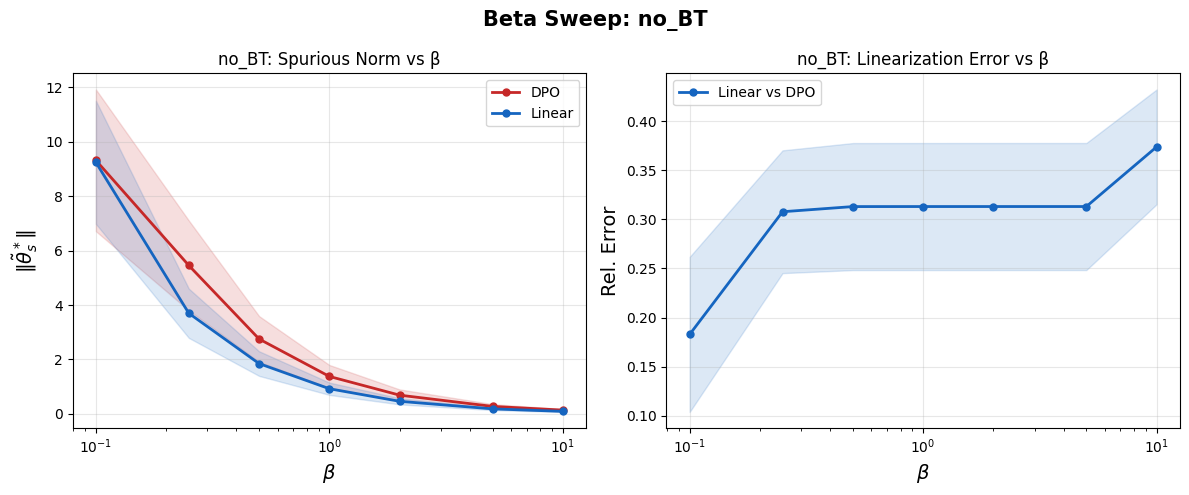

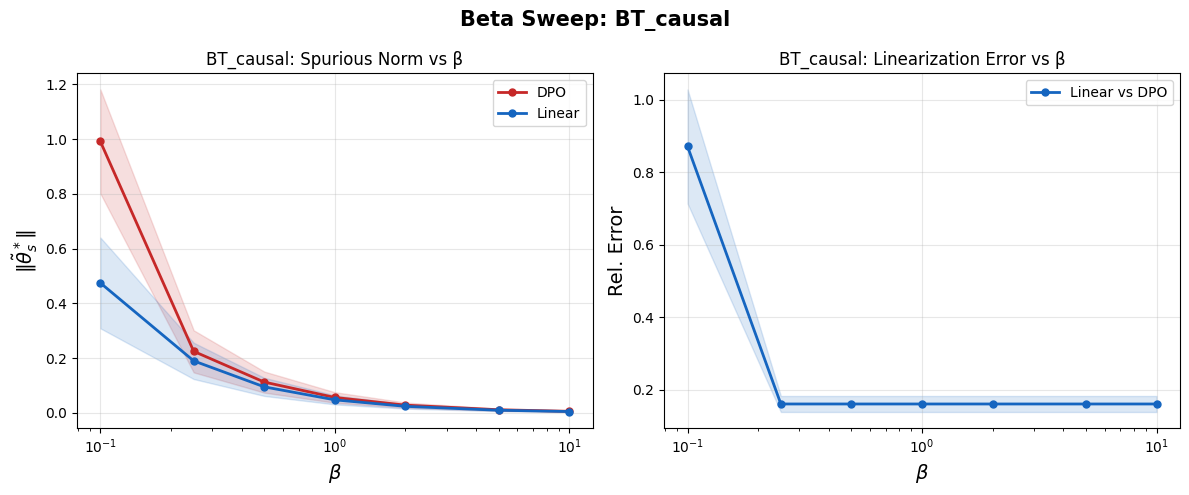

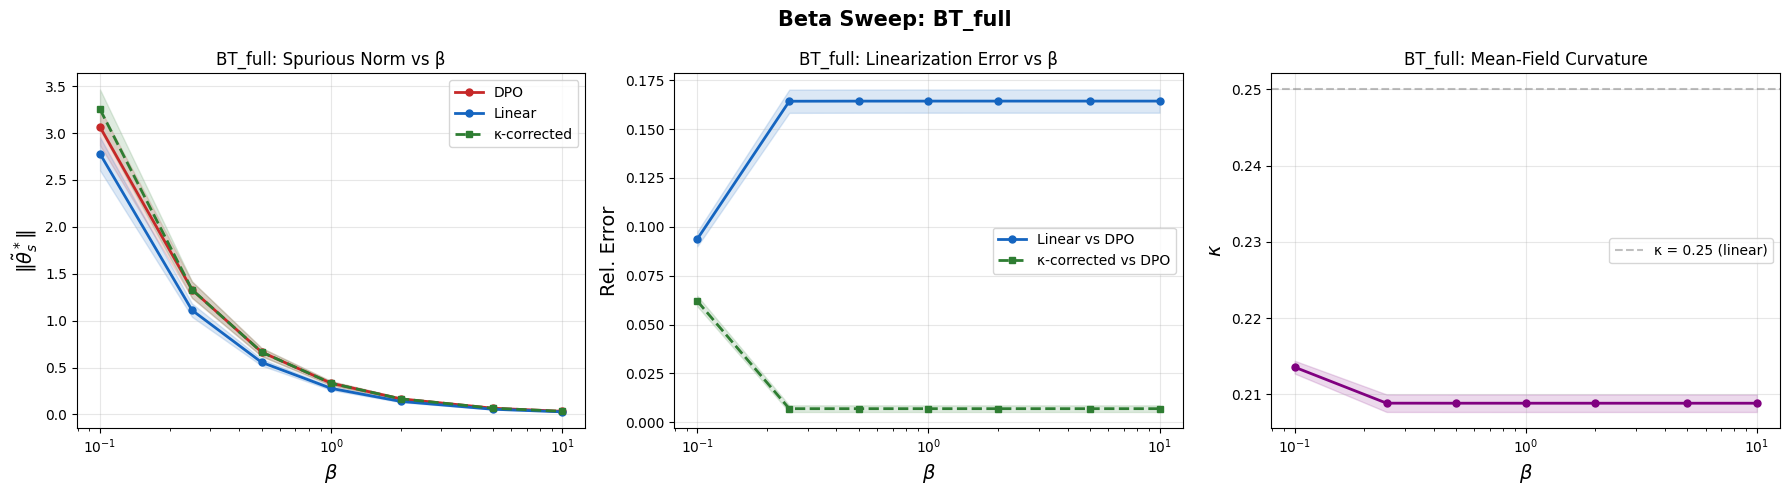

In [9]:
# =================================================================================================
# PART B: Beta sweeps — all levels, curvature correction on BT_full (disable cc for linear BT_full)
# =================================================================================================
for lvl in ["no_BT", "BT_causal", "BT_full"]:
    cc = (lvl == "BT_full")  # curvature correction only for level iii
    res = beta_sweep(level=lvl, n_samples=n_samples, d_c=d_c, d_s=d_s,
                     seed0=seed0, rho=0.5, theta_scale=0.3, mu_scale=0.3,
                     n_repeats=10, curvature_corrected=cc)
    plot_beta_sweep(res, lvl)



  Running SGD: no_BT, β=0.5, lr=0.005, steps=15000, n_runs=30


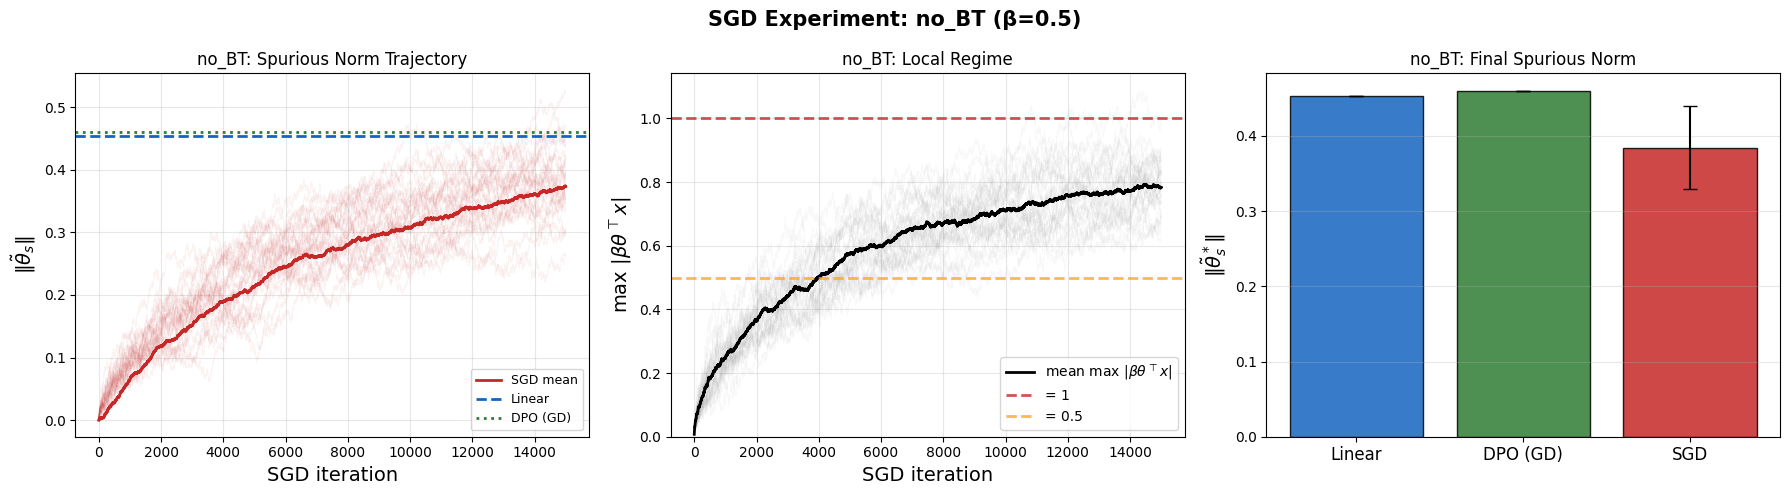


  Running SGD: BT_causal, β=0.5, lr=0.005, steps=15000, n_runs=30


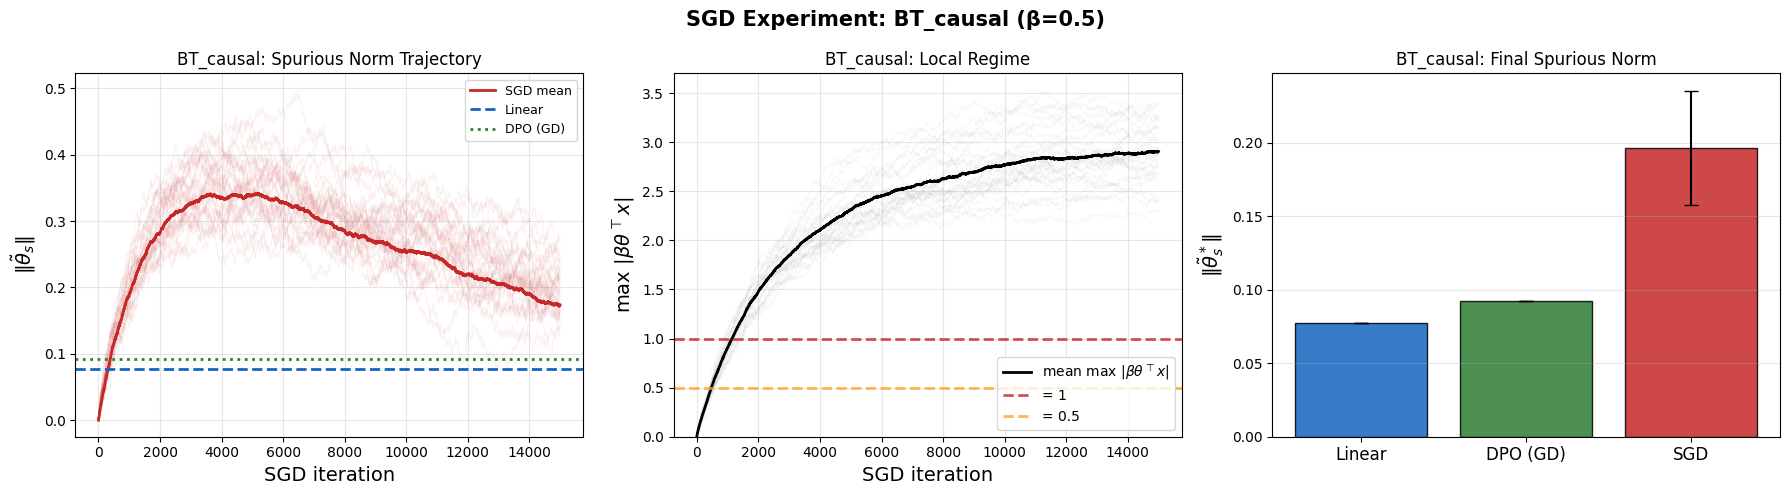


  Running SGD: BT_full, β=0.5, lr=0.005, steps=15000, n_runs=30


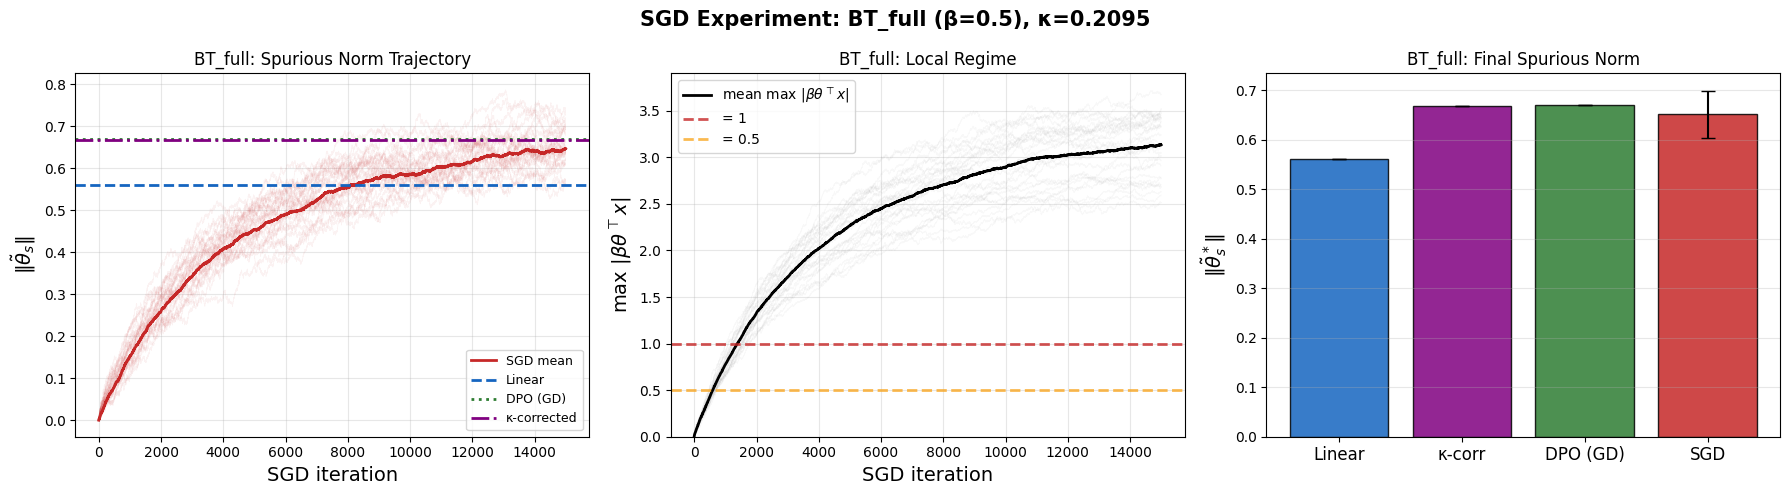


  Running SGD: BT_full, β=0.5, lr=0.005, steps=15000, n_runs=30


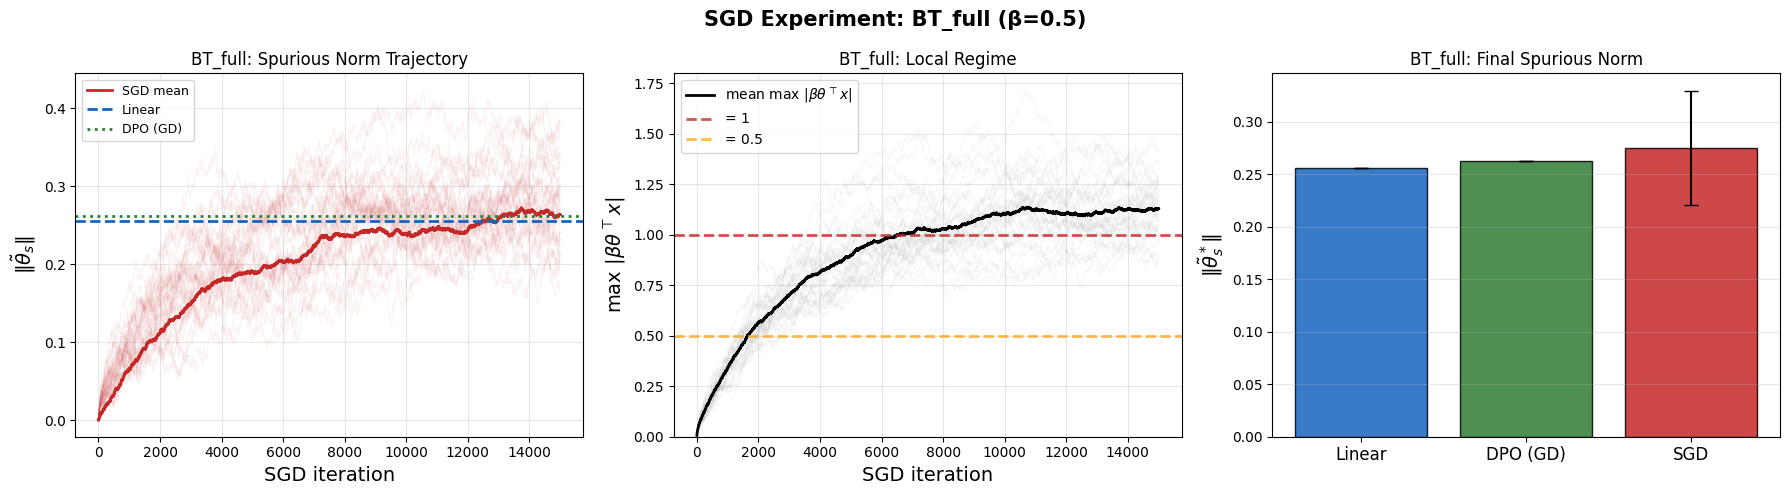

In [12]:
# =======================
# PART C: SGD experiments
# =======================
for lvl in ["no_BT", "BT_causal", "BT_full"]:
    cc = (lvl == "BT_full")
    res = sgd_experiment(level=lvl, n_samples=n_samples, d_c=d_c, d_s=d_s,
                         beta=0.5, lr=0.005, steps=15000, n_runs=30,
                         seed=seed0, rho=0.5, theta_scale=0.3, mu_scale=0.05,
                         curvature_corrected=cc)
    plot_sgd_experiment(res)

# Fourth: BT_full in the linear regime (small theta) — no correction needed
res = sgd_experiment(level="BT_full", n_samples=n_samples, d_c=d_c, d_s=d_s,
                     beta=0.5, lr=0.005, steps=15000, n_runs=30,
                     seed=seed0, theta_scale=0.1,
                     curvature_corrected=False)
plot_sgd_experiment(res)